# 03 — Feature Engineering

**Objectif :** transformer les données brutes de `v_delays_enriched` en un dataset Parquet prêt pour XGBoost.

**Ce qu'on fait ici :**
1. Charger et explorer les données depuis PostGIS
2. Analyser la distribution des délais et des features
3. Générer le dataset final avec `build_feature_dataset()`
4. Valider la qualité du dataset
5. Export en Parquet

## 0. Setup

In [52]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sqlalchemy import text

from src.utils.db import engine
from src.models.features import build_feature_dataset, FEATURE_COLUMNS, TARGET_COLUMN

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.2f}'.format)

print('Setup OK')

Setup OK


## 1. Aperçu des données collectées

In [53]:
# Vue d'ensemble des tables
with engine.connect() as conn:
    stats = conn.execute(text("""
        SELECT
            (SELECT COUNT(*) FROM stop_delays)      AS stop_delays,
            (SELECT COUNT(*) FROM weather_snapshots) AS weather_snapshots,
            (SELECT COUNT(*) FROM vehicle_positions) AS vehicle_positions,
            (SELECT COUNT(*) FROM v_delays_enriched WHERE temperature_c IS NOT NULL) AS enriched_joinable
    """)).fetchone()

print(f"stop_delays       : {stats.stop_delays:>10,} lignes")
print(f"weather_snapshots : {stats.weather_snapshots:>10,} lignes")
print(f"vehicle_positions : {stats.vehicle_positions:>10,} lignes")
print(f"v_delays_enriched : {stats.enriched_joinable:>10,} lignes (avec météo)")

stop_delays       : 53,654,350 lignes
weather_snapshots :         97 lignes
vehicle_positions :      3,329 lignes
v_delays_enriched : 53,654,350 lignes (avec météo)


In [54]:
# Couverture temporelle
with engine.connect() as conn:
    coverage = conn.execute(text("""
        SELECT
            MIN(collected_at) AT TIME ZONE 'America/Montreal' AS debut,
            MAX(collected_at) AT TIME ZONE 'America/Montreal' AS fin,
            ROUND(EXTRACT(EPOCH FROM (MAX(collected_at) - MIN(collected_at))) / 3600, 1) AS heures
        FROM stop_delays
    """)).fetchone()

print(f"Début   : {coverage.debut}")
print(f"Fin     : {coverage.fin}")
print(f"Durée   : {coverage.heures}h")

Début   : 2026-04-02 09:17:26.276483
Fin     : 2026-04-02 20:05:56.176007
Durée   : 10.8h


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


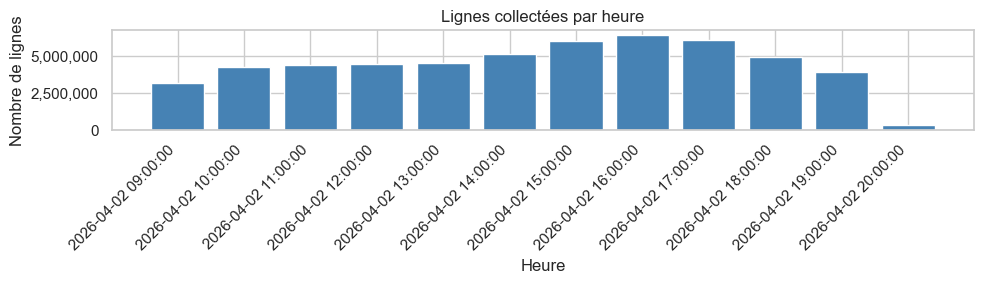

              heure  lignes
2026-04-02 09:00:00 3190852
2026-04-02 10:00:00 4271752
2026-04-02 11:00:00 4364664
2026-04-02 12:00:00 4448197
2026-04-02 13:00:00 4551406
2026-04-02 14:00:00 5131268
2026-04-02 15:00:00 6019995
2026-04-02 16:00:00 6417022
2026-04-02 17:00:00 6058884
2026-04-02 18:00:00 4938986
2026-04-02 19:00:00 3901213
2026-04-02 20:00:00  360111


In [55]:
# Distribution par heure — repérer les trous éventuels
with engine.connect() as conn:
    hourly = pd.read_sql(text("""
        SELECT
            date_trunc('hour', collected_at AT TIME ZONE 'America/Montreal') AS heure,
            COUNT(*) AS lignes
        FROM stop_delays
        GROUP BY 1
        ORDER BY 1
    """), conn)

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(hourly['heure'].astype(str), hourly['lignes'], color='steelblue')
ax.set_title('Lignes collectées par heure')
ax.set_xlabel('Heure')
ax.set_ylabel('Nombre de lignes')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(hourly.to_string(index=False))

## 2. Exploration des délais bruts

In [56]:
# Échantillon pour l'exploration (1% des données)
with engine.connect() as conn:
    df_sample = pd.read_sql(text("""
        SELECT *
        FROM v_delays_enriched
        WHERE temperature_c IS NOT NULL
        AND RANDOM() < 0.01
    """), conn)

print(f"{len(df_sample):,} lignes dans l'échantillon")
df_sample.head()

537,208 lignes dans l'échantillon


,id,route_id,stop_id,scheduled_at,delay_seconds,hour_of_day,day_of_week,week_of_year,is_rush_hour,temperature_c,precipitation_mm,wind_speed_kmh,is_precipitation
0,13818540,67,50815,2026-04-02 13:19:20+00:00,-35,9.00,4.00,14.00,True,0.30,0.00,15.60,False
1,13818832,61,52743,2026-04-02 13:44:00+00:00,0,9.00,4.00,14.00,True,0.30,0.00,15.60,False
2,13818905,93,51269,2026-04-02 13:33:50+00:00,0,9.00,4.00,14.00,True,0.30,0.00,15.60,False
3,13818930,189,53638,2026-04-02 13:29:40+00:00,0,9.00,4.00,14.00,True,0.30,0.00,15.60,False
4,13818939,189,54469,2026-04-02 13:34:23+00:00,0,9.00,4.00,14.00,True,0.30,0.00,15.60,False


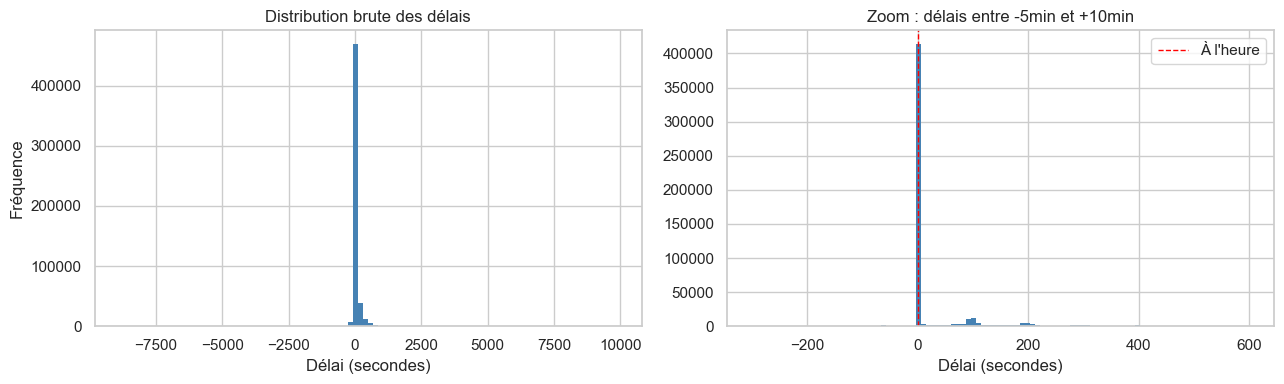

Statistiques des délais :
count   537208.00
mean        43.19
std        191.72
min      -8876.00
25%          0.00
50%          0.00
75%          0.00
max       9873.00
Name: delay_seconds, dtype: float64


In [57]:
# Distribution des délais bruts (avec outliers)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df_sample['delay_seconds'], bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Distribution brute des délais')
axes[0].set_xlabel('Délai (secondes)')
axes[0].set_ylabel('Fréquence')

# Zoom sur [-300s, +600s] pour voir la masse principale
df_zoom = df_sample[df_sample['delay_seconds'].between(-300, 600)]
axes[1].hist(df_zoom['delay_seconds'], bins=100, color='steelblue', edgecolor='none')
axes[1].set_title('Zoom : délais entre -5min et +10min')
axes[1].set_xlabel('Délai (secondes)')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1, label='À l\'heure')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Statistiques des délais :")
print(df_sample['delay_seconds'].describe())

In [58]:
# Pourcentage d'outliers (|delay| > 1h) — seront supprimés dans features.py
total = len(df_sample)
outliers = len(df_sample[~df_sample['delay_seconds'].between(-600, 3600)])
print(f"Outliers (|délai| > 1h) : {outliers:,} / {total:,} = {outliers/total*100:.2f}%")

Outliers (|délai| > 1h) : 381 / 537,208 = 0.07%


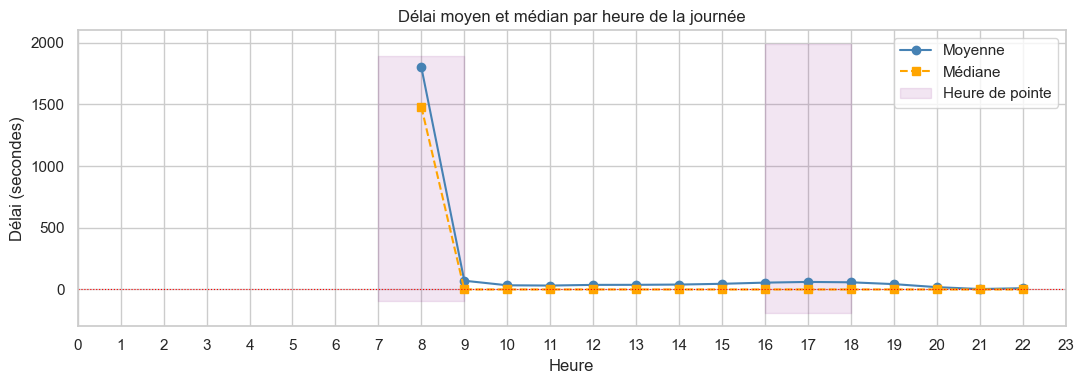

In [59]:
# Délais moyens par heure de la journée
with engine.connect() as conn:
    by_hour = pd.read_sql(text("""
        SELECT
            hour_of_day,
            AVG(delay_seconds) AS avg_delay,
            PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY delay_seconds) AS median_delay,
            COUNT(*) AS n
        FROM v_delays_enriched
        WHERE delay_seconds BETWEEN -600 AND 3600
          AND temperature_c IS NOT NULL
        GROUP BY 1
        ORDER BY 1
    """), conn)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(by_hour['hour_of_day'], by_hour['avg_delay'], marker='o', label='Moyenne', color='steelblue')
ax.plot(by_hour['hour_of_day'], by_hour['median_delay'], marker='s', linestyle='--', label='Médiane', color='orange')
ax.axhline(0, color='red', linewidth=0.8, linestyle=':')
ax.fill_between([7, 9], ax.get_ylim()[0], ax.get_ylim()[1], alpha=0.1, color='purple', label='Heure de pointe')
ax.fill_between([16, 18], ax.get_ylim()[0], ax.get_ylim()[1], alpha=0.1, color='purple')
ax.set_title('Délai moyen et médian par heure de la journée')
ax.set_xlabel('Heure')
ax.set_ylabel('Délai (secondes)')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.show()

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


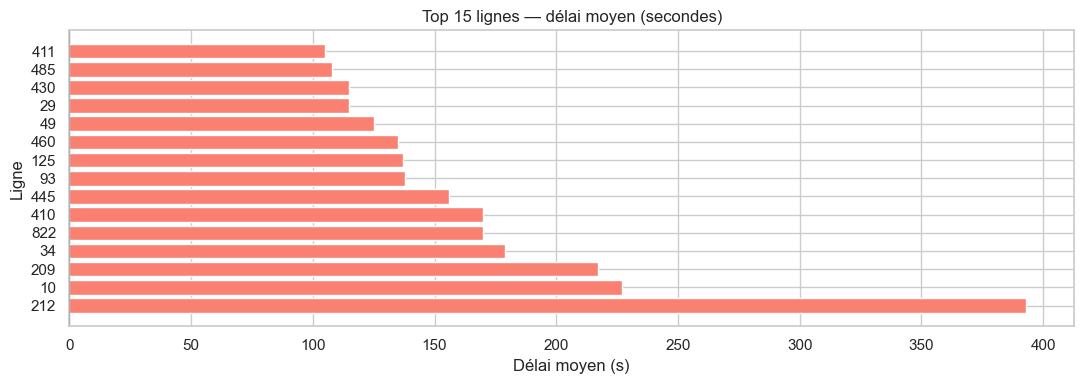

route_id  avg_delay  std_delay       n
     212     393.00     722.00   73410
      10     227.00     380.00  185206
     209     217.00     512.00  275337
      34     179.00     346.00  201802
     822     170.00     439.00   28611
     410     170.00     255.00   63589
     445     156.00     284.00   58827
      93     138.00     209.00  104532
     125     137.00     307.00  329006
     460     135.00     255.00  234129
      49     125.00     257.00 1014957
      29     115.00     198.00  175738
     430     115.00     256.00  129778
     485     108.00     222.00  244601
     411     105.00     212.00   51109


In [60]:
# Top 10 lignes les plus en retard
with engine.connect() as conn:
    by_route = pd.read_sql(text("""
        SELECT
            route_id,
            ROUND(AVG(delay_seconds)) AS avg_delay,
            ROUND(STDDEV(delay_seconds)) AS std_delay,
            COUNT(*) AS n
        FROM v_delays_enriched
        WHERE delay_seconds BETWEEN -600 AND 3600
          AND temperature_c IS NOT NULL
        GROUP BY 1
        HAVING COUNT(*) > 100
        ORDER BY avg_delay DESC
        LIMIT 15
    """), conn)

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.barh(by_route['route_id'].astype(str), by_route['avg_delay'], color='salmon')
ax.set_title('Top 15 lignes — délai moyen (secondes)')
ax.set_xlabel('Délai moyen (s)')
ax.set_ylabel('Ligne')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()
print(by_route.to_string(index=False))

## 3. Analyse des features

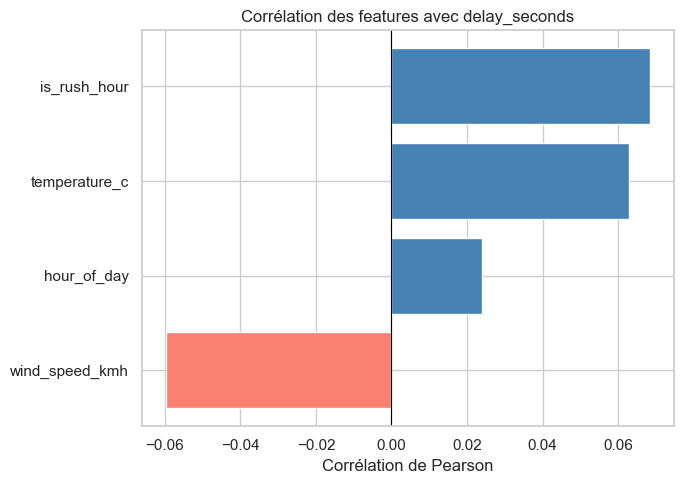

                  delay_seconds
wind_speed_kmh            -0.06
hour_of_day                0.02
temperature_c              0.06
is_rush_hour               0.07
day_of_week                 NaN
week_of_year                NaN
precipitation_mm            NaN
is_precipitation            NaN


In [61]:
# Corrélations avec delay_seconds
df_clean = df_sample[df_sample['delay_seconds'].between(-600, 3600)].copy()
df_clean['is_rush_hour'] = df_clean['is_rush_hour'].astype(int)
df_clean['is_precipitation'] = df_clean['is_precipitation'].astype(int)

numeric_cols = ['hour_of_day', 'day_of_week', 'week_of_year', 'is_rush_hour',
                'temperature_c', 'precipitation_mm', 'wind_speed_kmh', 'is_precipitation',
                'delay_seconds']

corr = df_clean[numeric_cols].corr()[['delay_seconds']].drop('delay_seconds').sort_values('delay_seconds')

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['salmon' if v < 0 else 'steelblue' for v in corr['delay_seconds']]
ax.barh(corr.index, corr['delay_seconds'], color=colors)
ax.set_title('Corrélation des features avec delay_seconds')
ax.set_xlabel('Corrélation de Pearson')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()
print(corr)

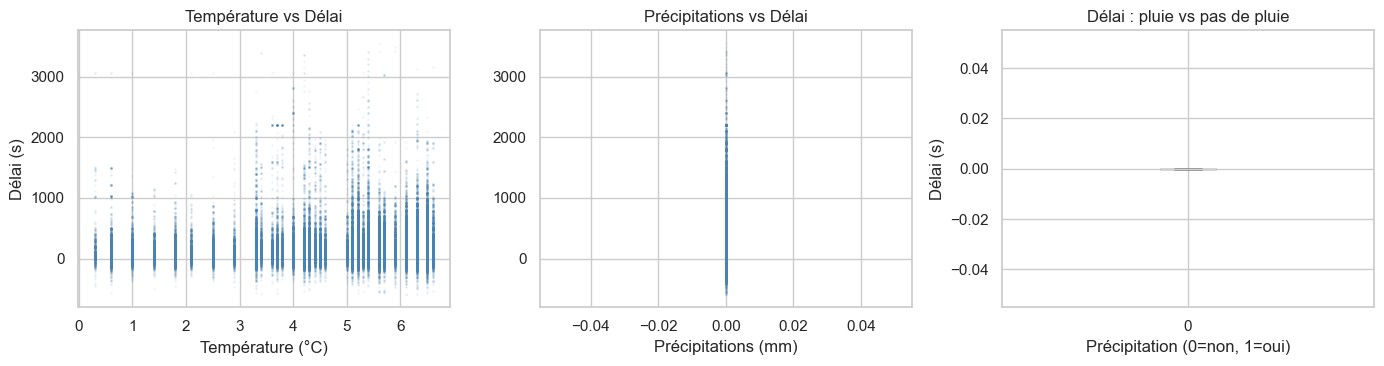

In [62]:
# Impact de la météo sur les délais
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Température
axes[0].scatter(df_clean['temperature_c'], df_clean['delay_seconds'],
                alpha=0.05, s=1, color='steelblue')
axes[0].set_title('Température vs Délai')
axes[0].set_xlabel('Température (°C)')
axes[0].set_ylabel('Délai (s)')

# Précipitations
axes[1].scatter(df_clean['precipitation_mm'], df_clean['delay_seconds'],
                alpha=0.05, s=1, color='steelblue')
axes[1].set_title('Précipitations vs Délai')
axes[1].set_xlabel('Précipitations (mm)')

# Avec/sans pluie (boxplot)
df_clean.boxplot(column='delay_seconds', by='is_precipitation', ax=axes[2],
                 showfliers=False, patch_artist=True,
                 boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[2].set_title('Délai : pluie vs pas de pluie')
axes[2].set_xlabel('Précipitation (0=non, 1=oui)')
axes[2].set_ylabel('Délai (s)')
plt.suptitle('')

plt.tight_layout()
plt.show()

## 4. Génération du dataset final

> **Note sur le data leakage :** on ne fait PAS de train/test split ici. Le split sera fait chronologiquement dans le notebook d'entraînement (notebook 04). Ne jamais couper aléatoirement une série temporelle.

In [63]:
# Générer le dataset complet via features.py
import logging
logging.basicConfig(level=logging.INFO, format='%(message)s')

OUTPUT_PATH = '../data/features/dataset.parquet'

df = build_feature_dataset(output_path=OUTPUT_PATH)
print(f"\nDataset final : {len(df):,} lignes × {len(df.columns)} colonnes")

[Features] Lecture depuis v_delays_enriched...
[Features] 53654350 lignes brutes chargées
[Features] 39492 outliers supprimés (|delay| > 1h)
[Features] 53614858 lignes finales
[Features] Dataset exporté → ../data/features/dataset.parquet



Dataset final : 53,614,858 lignes × 11 colonnes


## 5. Validation du dataset

In [64]:
print("=== Statistiques descriptives ===")
df.describe()

=== Statistiques descriptives ===


,hour_of_day,day_of_week,week_of_year,is_rush_hour,temperature_c,precipitation_mm,wind_speed_kmh,is_precipitation,delay_seconds,route_id_encoded
count,53614858.00,53614858.00,53614858.00,53614858.00,53614858.00,53614858.00,53614858.00,53614858.00,53614858.00,53614858.00
mean,15.04,4.00,14.00,0.36,4.57,0.00,13.24,0.00,44.97,88.26
std,3.01,0.00,0.00,0.48,1.61,0.00,3.21,0.00,150.75,53.24
min,8.00,4.00,14.00,0.00,0.30,0.00,7.10,0.00,-600.00,0.00
25%,13.00,4.00,14.00,0.00,3.70,0.00,11.20,0.00,0.00,42.00
50%,15.00,4.00,14.00,0.00,5.10,0.00,13.00,0.00,0.00,81.00
75%,17.00,4.00,14.00,1.00,5.70,0.00,16.20,0.00,0.00,140.00
max,22.00,4.00,14.00,1.00,6.60,0.00,18.40,0.00,3597.00,184.00


In [65]:
print("=== Valeurs manquantes ===")
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else "Aucune valeur manquante ✓")

=== Valeurs manquantes ===
Aucune valeur manquante ✓


=== Distribution de la target ===


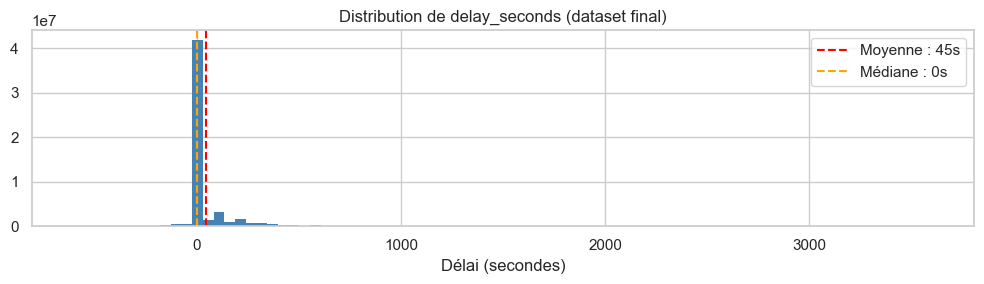

In [66]:
print("=== Distribution de la target ===")
fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(df['delay_seconds'], bins=80, color='steelblue', edgecolor='none')
ax.axvline(df['delay_seconds'].mean(), color='red', linestyle='--', label=f"Moyenne : {df['delay_seconds'].mean():.0f}s")
ax.axvline(df['delay_seconds'].median(), color='orange', linestyle='--', label=f"Médiane : {df['delay_seconds'].median():.0f}s")
ax.set_title('Distribution de delay_seconds (dataset final)')
ax.set_xlabel('Délai (secondes)')
ax.legend()
plt.tight_layout()
plt.show()

In [67]:
print("=== Nombre de lignes par ligne de bus ===")
route_counts = df['route_id_encoded'].value_counts()
print(f"Lignes de bus distinctes : {len(route_counts)}")
print(f"Min observations / ligne : {route_counts.min():,}")
print(f"Max observations / ligne : {route_counts.max():,}")
print(f"Médiane                  : {route_counts.median():,.0f}")

=== Nombre de lignes par ligne de bus ===
Lignes de bus distinctes : 185
Min observations / ligne : 731
Max observations / ligne : 1,525,617
Médiane                  : 220,992


In [68]:
# Vérification finale
import os
size_mb = os.path.getsize(OUTPUT_PATH) / 1024 / 1024
print(f"Fichier Parquet : {OUTPUT_PATH}")
print(f"Taille          : {size_mb:.1f} MB")
print(f"Lignes          : {len(df):,}")
print(f"Colonnes        : {list(df.columns)}")
print()
if len(df) >= 10_000:
    print("✓ Dataset suffisant pour l'entraînement (≥ 10 000 lignes)")
else:
    print(f"⚠ Seulement {len(df):,} lignes — collecte plus de données avant d'entraîner")

Fichier Parquet : ../data/features/dataset.parquet
Taille          : 144.5 MB
Lignes          : 53,614,858
Colonnes        : ['route_id', 'hour_of_day', 'day_of_week', 'week_of_year', 'is_rush_hour', 'temperature_c', 'precipitation_mm', 'wind_speed_kmh', 'is_precipitation', 'delay_seconds', 'route_id_encoded']

✓ Dataset suffisant pour l'entraînement (≥ 10 000 lignes)


## 6. Prochaines étapes

- [x] Dataset exporté dans `data/features/dataset.parquet`
- [ ] Ouvrir `04_model_evaluation.ipynb` pour entraîner XGBoost
- [ ] Démarrer MLflow : décommenter le service dans `docker-compose.yml`, puis `docker-compose up mlflow -d`